<a href="https://colab.research.google.com/github/mqquiroz/ICV513/blob/main/Estado_de_Mar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [223]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO

def zero_downcrossing(t,eta):
  #Algoritmo Zero-DownCrossing
  eta_max = 0
  eta_min = 0

  t0 = np.array([])
  H  = np.array([])

  for n in range(len(eta)-1):
    eta_max = np.max([eta[n+1],eta_max])
    eta_min = np.min([eta[n+1],eta_min])
    if (eta[n]>0) & (eta[n+1]<=0):
      t0 = np.append(t0,t[n] - ((t[n+1]-t[n])/(eta[n+1]-eta[n]))*eta[n])
      H = np.append(H,eta_max - eta_min)
      eta_max = 0
      eta_min = 0

  #Eliminamos el primer H (no es válido)
  H = H[1:]
  #Calculamos los periodos
  T  = np.array([])
  for n in range(len(t0)-1):
    T = np.append(T,t0[n+1]-t0[n])

  return H,T,t0

In [224]:
#Cargar serie de tiempo (datos) de Estado de Mar (desde GitHub)
url = 'https://raw.githubusercontent.com/mqquiroz/ICV513/refs/heads/main/F3-4.dat'
data = requests.get(url)
data = data.text
data = StringIO(data)
#print(data)
data   = np.loadtxt(data,skiprows=3)

#Cargar serie de tiempo (datos) desde carpeta de Google Colab (Otra opción)
#data   = np.loadtxt('F3-4.dat',skiprows=3)

tiempo = data[:,0]/60 #Primera columna tiempos (min)
eta    = data[:,1] #Segunda columna eta (m)


eta_mean = np.mean(eta) # eta promedio (m)
eta      = eta - eta_mean # a eta le restamos la media

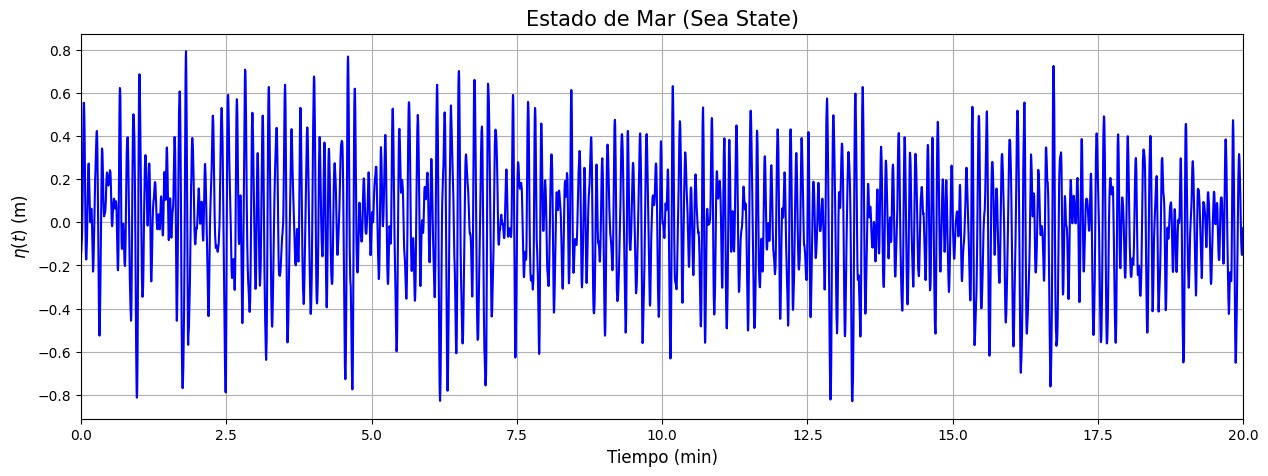

In [225]:
# Crearemos la figura a nuestra necesidad (antojo)
ancho = 15
alto  = 5

letra = 12

#Declaramos figura (fig) y eje (ax)
fig, ax = plt.subplots(figsize=(ancho,alto))

ax.plot(tiempo,eta,'b')
#plt.axhline(y=np.mean(eta),color='r')
ax.set_xlim([0,20])
ax.set_xlabel('Tiempo (min)',fontsize=letra)
ax.set_ylabel('$\eta(t)$ (m)',fontsize=letra)
ax.set_title('Estado de Mar (Sea State)',fontsize=letra+3)
ax.grid()
plt.show()

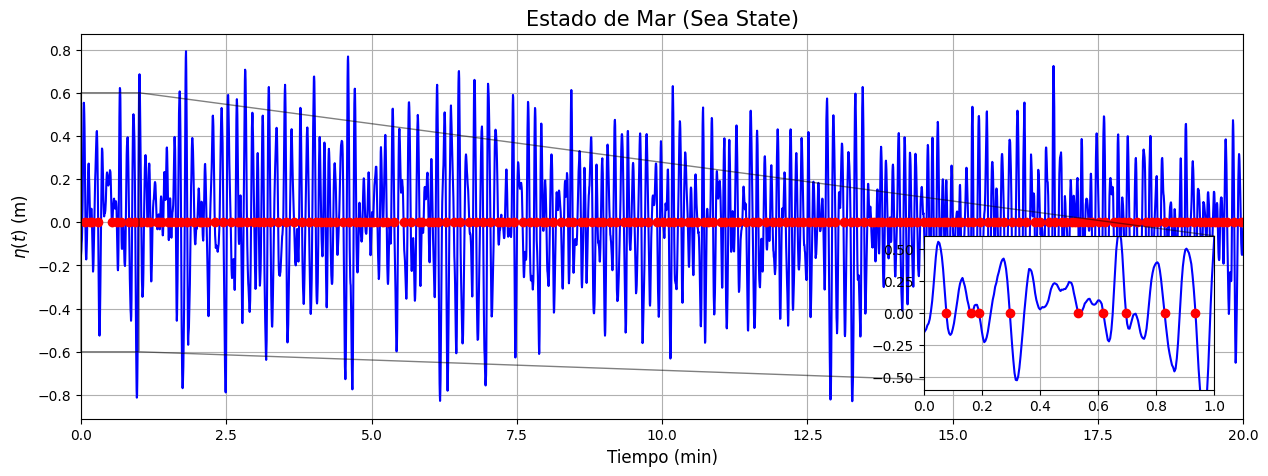

In [226]:
# Aplicación de Zero-DownCrossing para obtener ondas individuales
H,T,t0 = zero_downcrossing(tiempo,eta)

#Declaramos figura (fig) y eje (ax)
fig2, ax2 = plt.subplots(figsize=(ancho,alto))

ax2.plot(tiempo,eta,'b')
ax2.plot(t0,0*np.zeros(len(t0)),'or')
#plt.axhline(y=np.mean(eta),color='r')
ax2.set_xlim([0,20])
ax2.set_xlabel('Tiempo (min)',fontsize=letra)
ax2.set_ylabel('$\eta(t)$ (m)',fontsize=letra)
ax2.set_title('Estado de Mar (Sea State)',fontsize=letra+3)
ax2.grid()

# inset Axes....
x1, x2, y1, y2 = 0, 1, -0.6, 0.6  # subregion of the original image
axins = ax2.inset_axes([0.725, 0.075, 0.25, 0.4],xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[], yticklabels=[])
axins.plot(tiempo,eta,'b')
axins.plot(t0,0*np.zeros(len(t0)),'or')
axins.grid()

ax2.indicate_inset_zoom(axins, edgecolor="black")

plt.show()

In [63]:
#Calculo de parámetros de resumen del estado de Mar

#Alturas
#Altura Media (Promedio)
Hmedia = np.mean(H)
print('H_media = ',np.round(Hmedia,2),' (m)')

#Altura Media Cuadrática (root mean Squared)
Hrms = np.sqrt(np.mean(H**2))
print('H_rms = ',np.round(Hrms,2),' (m)')

#Altura Significativa
Hord = np.sort(H)[::-1]
N = len(Hord)
nn = int(N/3)
Hs = np.mean(Hord[:nn])
print('H_s = ',np.round(Hs,2),' (m)')

#Periodos
#Periodo Medio (Promedio)
Tmedio = np.mean(T) # (min)
print('T_medio = ',np.round(Tmedio*60,2),' (s)')

#Periodo Significativo
index_sortH = np.argsort(H)[::-1]
Tord        = T[index_sortH]
Ts          = np.mean(Tord[:nn])
print('T_s = ',np.round(Ts*60,2),' (s)')

H_media =  0.68  (m)
H_rms =  0.76  (m)
H_s =  1.05  (m)
T_medio =  6.05  (s)
T_s =  7.08  (s)


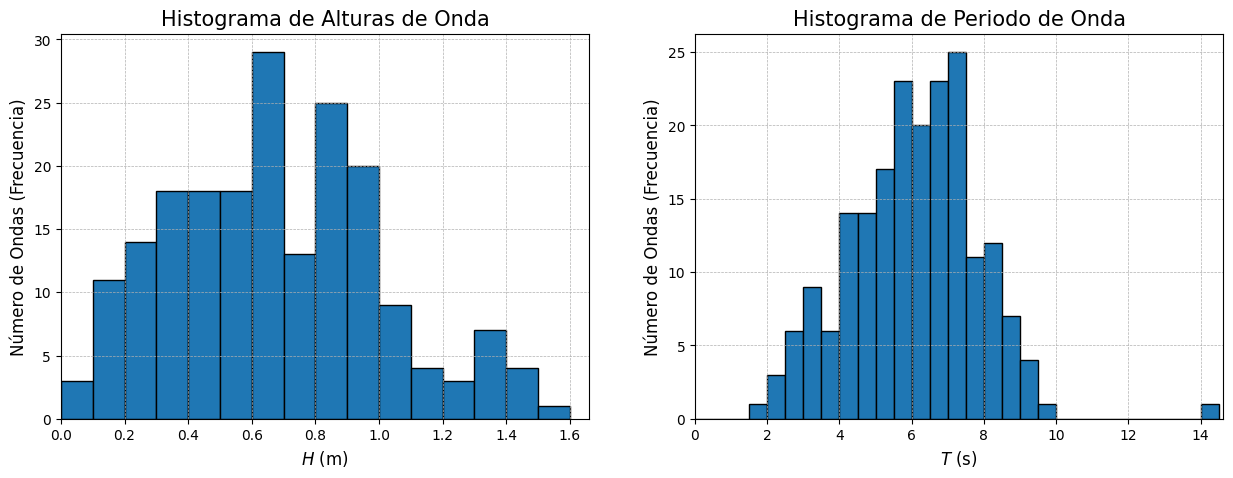

In [227]:
#Histograma de Altura de ondas y Periodos
#Declaramos figura (fig) y eje (ax)
fig3, ax3 = plt.subplots(1,2,figsize=(ancho,alto))

binwidth = 0.1
ax3[0].hist(H,bins=np.arange(0, max(H) + binwidth, binwidth),edgecolor='black')
ax3[0].set_xlim([0,max(H) + binwidth])
ax3[0].set_xlabel('$H$ (m)',fontsize=letra)
ax3[0].set_ylabel('Número de Ondas (Frecuencia)',fontsize=letra)
ax3[0].set_title('Histograma de Alturas de Onda',fontsize=letra+3)
ax3[0].grid(linewidth=0.5,linestyle='--')

binwidth2 = 0.5
ax3[1].hist(T*60,bins=np.arange(0, max(T*60) + binwidth2, binwidth2),edgecolor='black')
ax3[1].set_xlim([0,max(T*60) + binwidth2])
ax3[1].set_xlabel('$T$ (s)',fontsize=letra)
ax3[1].set_ylabel('Número de Ondas (Frecuencia)',fontsize=letra)
ax3[1].set_title('Histograma de Periodo de Onda',fontsize=letra+3)
ax3[1].grid(linewidth=0.5,linestyle='--')

plt.show()

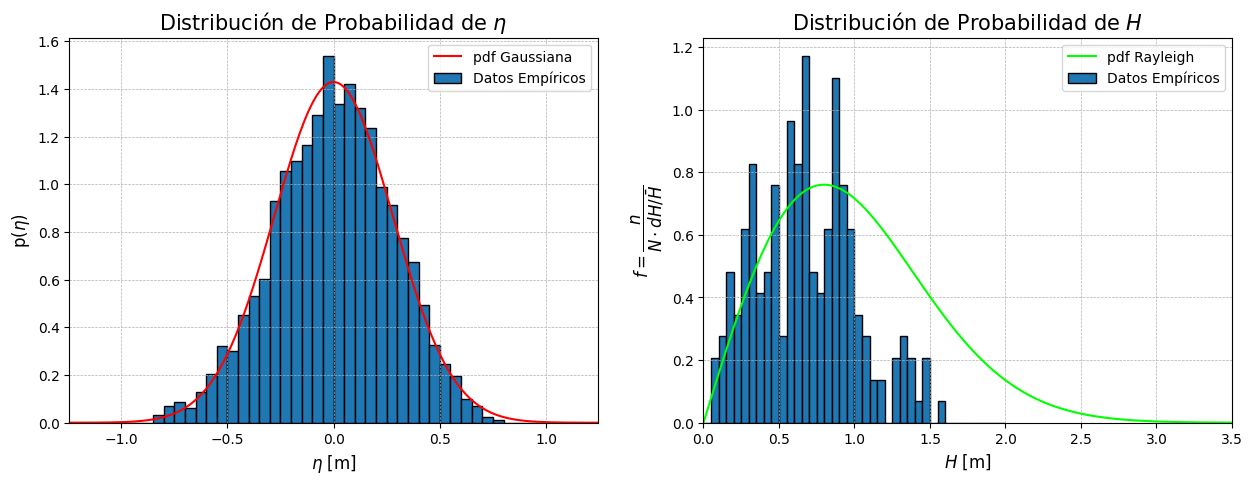

In [228]:
#Distribución de Probabilidad Gausiana sobre la superficie libre (\eta)
deta = 0.05 # ancho de los bins
etamax = 1.5
etamin = -etamax
bin_edges_eta = np.arange(etamin,etamax+deta,deta) #bordes de los bins

n_eta = np.histogram(eta,bins = bin_edges_eta)[0] # n para cada bin
f_eta = n_eta/np.sum(n_eta)*1/deta

# Distribución Gaussiana
dxx = 0.01
xx = np.arange(1.5*etamin,1.5*etamax+dxx,dxx)
m0n = np.var(eta)  # momento de orden zero (variance)
gaussiana_pdf = 1/(2*np.pi*m0n)**0.5*np.exp(-xx**2/(2*m0n)) # Distribución Gaussiana

#Distribución de Probabilidad de Rayleigh sobre Alturas de Onda
dH  = 0.05
Hmax = 2
bin_edges = np.arange(0,Hmax+dH,dH)

n = np.histogram(H,bins = bin_edges)[0]
f = n/np.sum(n)*1/(dH/Hmedia)

dx = 0.01
x = np.arange(0,5+dx,dx)
rayleigh_pdf = (np.pi/2)*x*np.exp((-np.pi/4)*(x**2))

#Declaramos figura (fig) y eje (ax)
fig4, ax4 = plt.subplots(1,2,figsize=(ancho,alto))

#eta
ax4[0].bar(bin_edges_eta[:-1],f_eta,deta,edgecolor = 'black',align='edge',label='Datos Empíricos')
ax4[0].plot(xx,gaussiana_pdf,'r',label='pdf Gaussiana')
limite = np.max(np.abs([np.min(eta),np.max(eta)]))
ax4[0].set_xlim([-1.5*limite,1.5*limite])
ax4[0].set_title('Distribución de Probabilidad de $\eta$',fontsize=letra+3)
ax4[0].set_xlabel('$\eta$ [m]',fontsize=letra)
ax4[0].set_ylabel('p($\eta$)',fontsize=letra)
ax4[0].legend()
ax4[0].grid(linewidth=0.5,linestyle='--')

#H
ax4[1].bar(bin_edges[:-1],f,dH,edgecolor = 'black',align='edge',label='Datos Empíricos')
ax4[1].plot(x,rayleigh_pdf,'lime',label='pdf Rayleigh')
ax4[1].set_xlabel('$H$ [m]',fontsize=letra)
ax4[1].set_ylabel(r'$f = \dfrac{n}{N\cdot dH/\bar{H}}$',fontsize=letra)
ax4[1].set_xlim([0,1.75*Hmax])
ax4[1].set_title('Distribución de Probabilidad de $H$',fontsize=letra+3)
ax4[1].legend()
ax4[1].grid(linewidth=0.5,linestyle='--')

plt.show()